# *LompeOSSE* example - SMILE UVI


This notebook demonstrates how to apply the *LompOSSE* module in a representative Observation System Simulation Experiment (OSSE). 

*The Ultraviolet Imager (UVI) is one of four instruments onboard the Solar wind Magnetosphere Ionosphere Link Explorer (SMILE) satellite (launch planned for 2026). UVI will capture the global auroral images (covering the entire auroral oval), which depict the energy depositions in the solar wind-magnetosphere coupling system.* 

The aim of this OSSE is to evaluate how well global ionospheric electrodynamics can be reconstructed when SMILE UVI provides the only source of conductance information. (OK??)

### Imports

In [ ]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib as plt
import apexpy
import lompe
from lompe.model.cmodel import Cmodel
from lompe.model.visualization import *
import h5py
import matplotlib.gridspec as gridspec
import secsy as cs
import sys, os
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))  # go one level up from notebook dir
sys.path.append(repo_root)
from lompeosse import LompeOSSE

Path for example data files

In [2]:
lompe_dir = os.path.dirname(os.path.abspath(lompe.__file__))
data_dir = os.path.join(lompe_dir, '../examples/sample_dataset')

### Configure electric field model input

#### Grid
In this example, we define a global grid that covers the entire auroral region in the Northern hemisphere (≈ 50°–90° latitude) so that the observation geometry corresponds to the SMILE UVI viewing conditions. This grid provides the spatial framework on which the electrodynamics will be reconstructed.

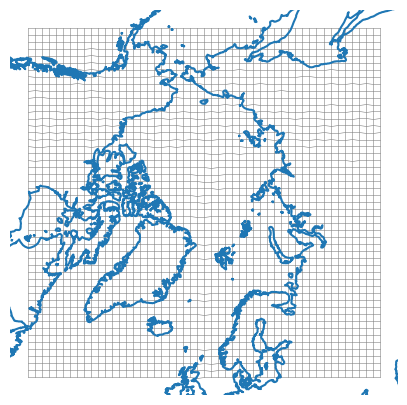

50 x 50 cubed sphere grid
Centered at lon, lat = 0.0, 90.0
Orientation: 1.00 east, 0.00 north, 
Extent: ~64.3 x 64.3 degrees central angle

In [3]:
# Center of the grid
lonc, latc = 0, 90         # center latitude ~90°N, center longitude 0°
position = (lonc, latc)    # center position
orientation = 0            # orientation angle in degrees (0 = North up)

# Grid dimensions and resolution
L, W, Lres, Wres = 15000e3, 15000e3, 150e3, 150e3 # [m]

# Gamera ionospheric radius
RG = 6500 # [km]

# Construct the cubed sphere grid
grid = lompe.cs.CSgrid(
    lompe.cs.CSprojection(position, orientation),
    L, W, Lres, Wres,
    R=RG * 1e3  # [m]
    )

# Plot grid and coastlines
fig, ax0 = plt.subplots(figsize = (5, 5))
ax0.set_axis_off()
for lon, lat in grid.get_grid_boundaries():
    xi, eta = grid.projection.geo2cube(lon, lat)
    ax0.plot(xi, eta, color = 'grey', linewidth = .4)

xlim, ylim = ax0.get_xlim(), ax0.get_ylim()
for cl in grid.projection.get_projected_coastlines():
    ax0.plot(cl[0], cl[1], color = 'C0')
    
ax0.set_xlim(xlim)
ax0.set_ylim(ylim)
plt.show()

grid

#### Input data
Next, we load the observational datasets that will be used in this OSSE. 

We start by defining the event (date of observations).

In [4]:
# Define event date and time interval
event = "2012-04-05"
event_date = event.replace('-', '') # format YYYYMMDD
hour = 1
minute = 19
DT = dt.timedelta(minutes=2) # will select data from stime +- DT 

time = pd.to_datetime(event)
stime = dt.datetime(time.year, time.month, time.day, hour, minute) # specific time to model
t0 = stime - DT
t1 = stime + DT
print('Model interval is ' + str(t0) + ' UT to ' + str(t1) + ' UT')

# Define epoch and initialize Apex object for magnetic coordinate calculations 
epoch = time.year
apx = apexpy.Apex(epoch)

Model interval is 2012-04-05 01:17:00 UT to 2012-04-05 01:21:00 UT


Then we define a dictionnary that contains the paths for the datasets of our choice. These datasets provide complementary information on ionospheric electrodynamics. In this example, we use **SuperMAG** (horizontal ground magnetic field perturbations), **SuperDARN** (line-of-sight plasma convection measurements) and **Iridium/AMPERE** (horizontal magnetic field measurements) data.

In [5]:
# Dictionary of files
files = {
    "sdarnfn": (f"{event_date}_superdarn_grdmap.h5", "SuperDARN (radar)"),
    "smagfn":  (f"{event_date}_supermag.h5", "SuperMAG (ground magnetometers)"),
    "iridfn":  (f"{event_date}_iridium.h5", "Iridium"),
}

# Build absolute paths and check if files exist
for var, (filename, desc) in files.items():
    path = os.path.join(data_dir, filename)
    # print(path)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find {desc} data file at {path}")
    files[var] = (path, desc)  # overwrite filename with full path

# Load data
superdarn = pd.read_hdf(files["sdarnfn"][0])
supermag  = pd.read_hdf(files["smagfn"][0])
iridium   = pd.read_hdf(files["iridfn"][0])

Next, we filter the full-day datasets for the selected time window (here, ±2 minutes around 01:19 UT on 5 April 2012), and prepare Lompe Data objects. These objects will later be passed to the Lompe **Emodel** object.

For details on how to prepare different data sources for use with Lompe, see for example the notebook: *Data_handling_with_Lompe* (in the lompe/examples/ folder of the Lompe module).

In [6]:
def get_data_subsets(t0, t1):
    """ return subsets of data loaded above, between t0 and t1 """
    
    # SuperDARN data:
    sd = superdarn.loc[(superdarn.index >= t0) & (superdarn.index <= t1) & 
                        (superdarn.vlos < 2000)].dropna()
    sd_vlos = sd['vlos'].values
    sd_coords = np.vstack((sd['glon'].values, sd['glat'].values))
    sd_los  = np.vstack((sd['le'].values, sd['ln'].values))

    # SuperMAG data:
    smag = supermag[supermag.lat <= 90] # select northern hemisphere magnetometers? Necessarry?
    smag = smag[t0 : t1].dropna()
    smag_B = np.vstack((smag.Be.values, smag.Bn.values, smag.Bu.values)) # nT
    smag_coords = np.vstack((smag.lon.values, smag.lat.values))

    # Iridium/AMPERE data
    irid = iridium[(iridium.time >= t0) & (iridium.time <= t1)]

    if not irid.empty:
        irid_B = np.vstack((irid.B_e.values, irid.B_n.values, irid.B_r.values))
        irid_coords = np.vstack(
            (irid.lon.values, irid.lat.values, irid.r.values))
    else:
        irid_B = np.empty((3, 0))
        irid_coords = np.empty((2, 0))

    # Make the data objects (for Lompe)
    superdarn_data = lompe.Data(sd_vlos        , sd_coords  , LOS = sd_los , datatype = 'convection' , iweight = 1.0, error = 50)
    supermag_data  = lompe.Data(smag_B * 1e-9  , smag_coords,                datatype = 'ground_mag' , iweight = 0.0, error = 10e-9)
    iridium_data = lompe.Data(irid_B * 1e-9 if irid_B.size else irid_B, irid_coords, datatype="space_mag_fac", iweight = 1.0, error = 30e-9)
    # note the iweight=0.0 given to SuperMAG data to produce zero weight 
    
    return(superdarn_data, supermag_data, iridium_data)

# Get the data objects for specified time interval
sd_data, sm_data, irid_data = get_data_subsets(t0, t1)


##### Conductance (OK??)

Then we define the **condutance**. The ionospheric conductance is primarily controlled by ionization from solar EUV radiation. Here, we use a conductance model derived from SSUSI images as a proxy for the conductance that would be obtained from SMILE UVI observations.

Note: the Lompe technique always requires that ionospheric conductances are known.

In [7]:
cmod = Cmodel(grid, event, stime, spline_smoothing = 10, EUV = True, filtersize = 2, how = 'median', 
              param = 'lbhs', tempfile_path = data_dir, basepath = data_dir + '/raw/') #1000

### Generate electric field model 
Now that we have the condutance and datasets, we can set up the Lompe electric field model.

In [8]:
# Create Emodel object
model = lompe.Emodel(grid, (cmod.hall, cmod.pedersen))

# Add data to model
model.add_data(sd_data, sm_data, irid_data) 


### Derive OSSE model

In the previous steps we set up the baseline electric field model. The key feature of *LompeOSSE* is that the inversion for the electric field is performed on **synthetic data**. 

#### Gamera simulation dataset

We begin by loading the synthetic dataset:

In [9]:
# Build path to Gamera data file
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..")) # one level above notebook folder  
datapath = os.path.join(repo_root, "data/Gamera_data.h5")

# Check if data file exists
if not os.path.exists(datapath):
    raise FileNotFoundError(
        f"Required file not found: {datapath}\n"
        "Please download it (https://zenodo.org/records/16882035) and place it in the 'data' folder."
    )

# Open Gamera data file
Gdata = h5py.File(datapath, 'r')

# Print time steps available in Gamera dataset
for key in Gdata.keys():
    print(key)

Step#0
Step#12
Step#13
Step#14
Step#16
Step#19
Step#2
Step#20
Step#21
Step#22
Step#3
X
Y


Select time step of interest (use find-Gamera-snapshot.py to inspect available snapshots):


In [10]:
Gstep = 0 # e.g., if Gstep = 0, the selected time step is Step#0

Optional: Rotate the Gamera snapshot in magnetic local time (hours). This allows exploring multiple OSSE configurations from the same Gamera snapshot

In [11]:
mlt_offset = 0

#### **LompeOSSE** model

Here, we create the *LompeOSSE* model. This is done by replacing the real observational datasets in the baseline electric field model with synthetic data extracted from the selected Gamera snapshot. The grid, dataset types and coordinates are unchanged. 

In [ ]:
lompeosse_obj = LompeOSSE(model, nstep=Gstep, mlt_off=mlt_offset, epoch=epoch)
osse_model = lompeosse_obj.osse_model

Step#0
Hemisphere: NORTH
/Users/margot/Docs/Academia/Research/Python/lompe_osse/data/Gamera_data.h5
dict_keys(['X', 'Y', 'Average energy', 'Density', 'Field-aligned current', 'Hall conductance', 'IM Energy flux', 'IM Energy flux proton', 'IM average energy', 'IM average energy proton', 'Number flux', 'Pedersen conductance', 'Potential', 'Sound speed', 'Zhang average energy', 'Zhang number flux'])

 Initializing OSSE model...

 Scanning user datasets and searching for corresponding Gamera data...
efield dataset is empty
Gamera convection data extracted
radius: 6371.2 km
Gamera magnetic field data extracted (ground_mag)
space_mag_full dataset is empty
radius: [7155090.52728301 7154945.9539051  7154805.82546683 7154670.17425429
 7154539.80473633 7154413.78243777 7154293.59815087 7154178.19697887
 7154068.28692716 7153963.64449877 7153864.72984283 7153770.91838905
 7153682.96544628 7153898.73948036 7153994.28796541 7154095.33197265
 7154201.87963403 7154313.73713599 7154430.80906285 715455

### Run inversion to solve for electrodynamic quantities and visualize results
Finally, we can run the inversion on the LompeOSSE model:

In [13]:
# Run inversion
osse_model.run_inversion(l1 = 1, l2 = 1) # 1) model norm, and 2) gradient of SECS amplitudes (charges) in magnetic eastward direction

ground_mag: Measurement uncertainty effectively changed from 1e-08 to inf


(array([[ 5.52464253e-08,  5.56691973e-08,  5.59849955e-08, ...,
         -2.38131332e-08, -2.35191919e-08, -2.25603490e-08],
        [ 5.56691973e-08,  5.61525111e-08,  5.65297228e-08, ...,
         -2.37852490e-08, -2.34959130e-08, -2.25312798e-08],
        [ 5.59849955e-08,  5.65297228e-08,  5.69698460e-08, ...,
         -2.37206818e-08, -2.34364971e-08, -2.24669338e-08],
        ...,
        [-2.38131332e-08, -2.37852490e-08, -2.37206818e-08, ...,
          1.60342515e-08,  1.52358470e-08,  1.56399199e-08],
        [-2.35191919e-08, -2.34959130e-08, -2.34364971e-08, ...,
          1.52358470e-08,  1.57664204e-08,  1.32867039e-08],
        [-2.25603490e-08, -2.25312798e-08, -2.24669338e-08, ...,
          1.56399199e-08,  1.32867039e-08,  1.72475298e-08]]),
 array([-0.00271526, -0.00252531, -0.00232735, ...,  0.00321886,
         0.00302934,  0.00286182]))

And plot the resulting 2D map of reconstructed ionospheric electrodynamics within the region (grid) defined earlier and using the datasets of our choice: 

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


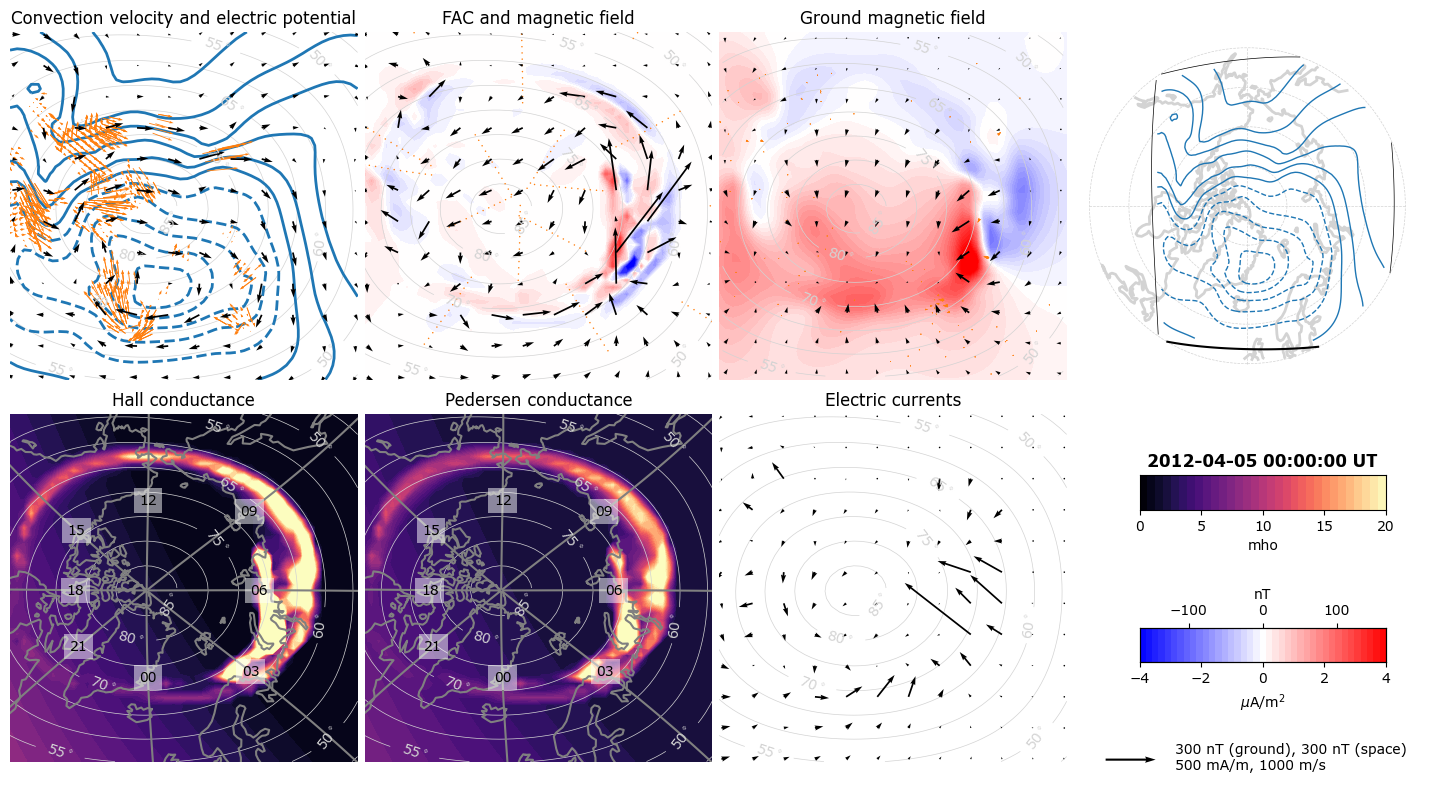

In [14]:
fig = lompe.lompeplot(osse_model, include_data = True, time = time, apex = apx, 
                      colorscales = {'fac'        : np.linspace(-2, 2, 40) * 1e-6 * 2,
                                     'ground_mag' : np.linspace(-500, 500, 50) * 1e-9 / 3, # upward component
                                     'hall'       : np.linspace(0, 20, 32), # mho
                                     'pedersen'   : np.linspace(0, 20, 32)}, # mho
                        quiverscales = {'ground_mag'       : 600*1e-9, 
                                        'space_mag_fac'    : 600*1e-9, 
                                        'space_mag_full'   : 600*1e-9, 
                                        'electric_current' : 1}) # 1000*1e-3
plt.show()

The top row shows, from left to right (input data is shown in orange): 
- Convection flow field and electric potential contours
- horizontal magnetic field disturbances 110 km above the ionosphere as black arrows and radial current density as color contours
- horizontal ground magnetic field perturbations as black arrows and radial magnetic field perturbations as color contours
- a map that shows the grid’s position and orientation with respect to apex magnetic latitude and local time.

The bottom row shows, from left to right: 
- Pedersen conductance
- Hall conductance
- horizontal height-integrated ionospheric currents based on Lompe output
- color scale / vector scales

## Validate the OSSE setup

Finally, we can validate our synthetic model against Gamera "truth". 



First, we extract the electrodynamics quantities of our choice from the LompeOSSE model:


In [15]:
# LompeOSSE-reconstructed quantities
potOSSE = osse_model.E_pot(lon=grid.lon, lat=grid.lat) * 1e-3 # V
potOSSE = potOSSE.reshape(grid.lon.shape)

facOSSE = osse_model.FAC(lon=grid.lon, lat=grid.lat)
facOSSE = facOSSE.reshape(grid.lon.shape)

Then we extract the same electrodynamics quantities from the Gamera simulation dataset, and interpolate them to the user-defined grid (grid used to derive the LompeOSSE model):

In [ ]:
hemisphere = 'NORTH' if latc > 0 else 'SOUTH'

# Extract electric potential and field-aligned currents from Gamera dataset
potG = Gdata[f'Step#{Gstep}']['Potential ' +hemisphere][:]
facG = Gdata[f'Step#{Gstep}']['Field-aligned current ' +hemisphere][:]

# Interpolate to LompeOSSE grid
interp_potG = lompeosse_obj.interp2lompegrid(potG)
interp_facG = lompeosse_obj.interp2lompegrid(facG)

Finally, plot both quantities next to each other:

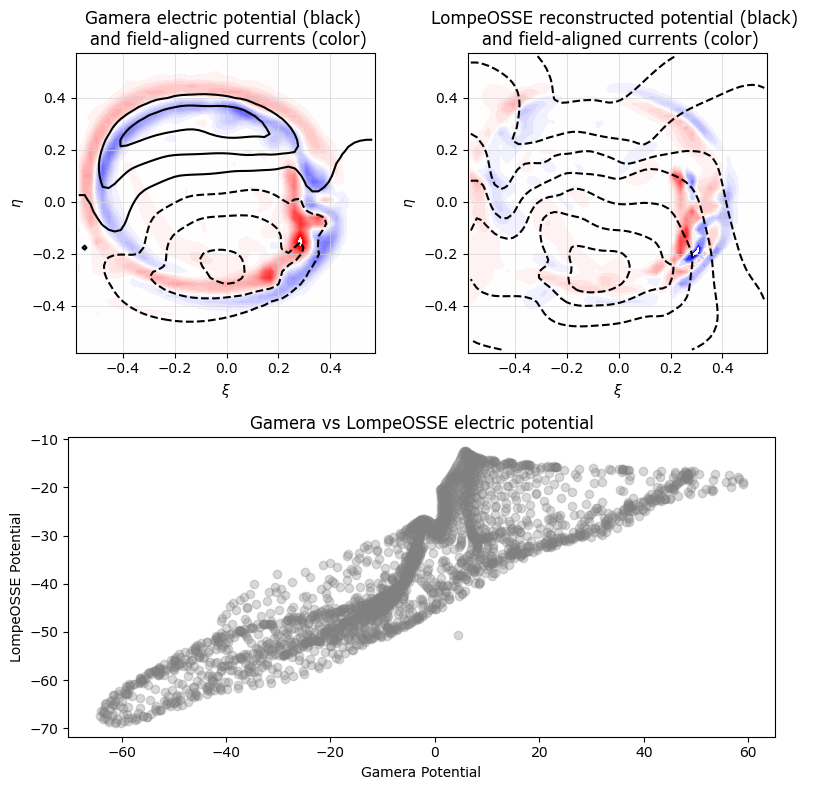

In [17]:
fac_levels = np.linspace(-1.95, 1.95, 40) * 1e-6 * 2

fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

# First panel (top-left): Gamera quantities
ax1 = fig.add_subplot(gs[0, 0])  
csax1 = cs.CSplot(ax1, grid, gridtype='cs')
csax1.contour(grid.lon, grid.lat, interp_potG, colors='k')
csax1.contourf(grid.lon, grid.lat, interp_facG*(-1), cmap='bwr', levels=fac_levels*1e6)
ax1.set_title("Gamera electric potential (black) \n and field-aligned currents (color)")

# Second panel (top-right): LompeOSSE-reconstructed quantities
ax2 = fig.add_subplot(gs[0, 1])  
csax2 = cs.CSplot(ax2, grid, gridtype='cs')
csax2.contour(grid.lon, grid.lat, potOSSE, colors='k')
csax2.contourf(grid.lon, grid.lat, facOSSE, cmap='bwr', levels=fac_levels)
ax2.set_title("LompeOSSE reconstructed potential (black) \n and field-aligned currents (color)")

# Third panel (bottom): Scatter plot Gamera VS Lompe-reconstructed potential (should be a line ish)
ax3 = fig.add_subplot(gs[1, :])
ax3.scatter(interp_potG, potOSSE, alpha=.3, color='grey')
ax3.set_xlabel("Gamera Potential")
ax3.set_ylabel("LompeOSSE Potential")
ax3.set_title("Gamera vs LompeOSSE electric potential")
# plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

We can also compute the correlation coefficient between Gamera truth and LompeOSSE-reconstructed quantity (here, the electric potential):

In [18]:
corr_coef = np.corrcoef(interp_potG.flatten(), potOSSE.flatten())[0, 1]
print(f"Correlation coefficient (Gamera vs LompeOSSE potential): \n {corr_coef:.3f}")

Correlation coefficient (Gamera vs LompeOSSE potential): 
 0.850
